# 📊 Analyse des Performances Étudiantes
### Étude de cas : Mathématiques & Portugais — Lycées Portugais (UCI Dataset)

---

## 🎯 Objectif du Notebook

Ce notebook analyse les facteurs qui influencent la réussite académique d'élèves dans deux matières : **Mathématiques** et **Portugais**. L'analyse se déroule en quatre parties :

| # | Partie | Technique | But |
|---|--------|-----------|-----|
| 1 | **Exploration des données (EDA)** | Statistiques + Visualisations | Comprendre la distribution des notes et les corrélations |
| 2 | **Préparation des données** | Encodage + Normalisation | Rendre les données exploitables par les algorithmes ML |
| 3 | **Clustering — Mathématiques** | K-Means | Identifier des profils d'élèves similaires |
| 4 | **Importance des variables — Mathématiques** | Random Forest | Quantifier l'impact de chaque facteur sur la note |
| 5 | **Analyse complète — Portugais** | K-Means + PCA + Random Forest | Reproduire l'analyse et comparer les deux matières |

---

## 📂 Source des Données

Le dataset provient de l'[UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Student+Performance). Il contient des informations sur des lycéens portugais collectées par questionnaire : habitudes de vie, contexte familial, données scolaires.

**Variables clés :**
- `G1`, `G2`, `G3` : Notes des périodes 1, 2 et finale (sur 20)
- `studytime` : Temps d'étude hebdomadaire (1 à 4)
- `failures` : Nombre d'échecs antérieurs
- `absences` : Nombre d'absences
- `Walc`, `Dalc` : Consommation d'alcool le week-end / en semaine (1 à 5)
- `higher` : Souhait de faire des études supérieures (yes/no)

---
# Partie 1 — Exploration des Données (EDA)

## Objectif
Avant d'appliquer tout algorithme, il est essentiel de **comprendre les données brutes** : distribution des notes, corrélations entre variables, et différences entre les deux matières.

## Choix techniques
- On **concatène** les deux jeux de données (mat + por) avec une colonne `matiere` pour pouvoir les comparer côte à côte.
- On utilise **4 visualisations complémentaires** : une distribution pour les notes, un boxplot pour le temps d'étude, un boxplot pour l'alcool, et une heatmap de corrélation.

In [ ]:
%pip install seaborn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Chargement des données ---
# Le séparateur standard du dataset UCI est le point-virgule.
# Un test de fallback est inclus au cas où le fichier utilise la virgule.
df_mat = pd.read_csv('data/student-mat.csv', sep=';')
if len(df_mat.columns) == 1:
    df_mat = pd.read_csv('data/student-mat.csv', sep=',')
df_mat['matiere'] = 'Mathématiques'

df_por = pd.read_csv('data/student-por.csv', sep=';')
if len(df_por.columns) == 1:
    df_por = pd.read_csv('data/student-por.csv', sep=',')
df_por['matiere'] = 'Portugais'

# Concaténation pour une vue globale
df = pd.concat([df_mat, df_por], ignore_index=True)

print("✅ Données chargées avec succès.")
print(f"   → Mathématiques : {len(df_mat)} étudiants, {df_mat.shape[1]} variables")
print(f"   → Portugais     : {len(df_por)} étudiants, {df_por.shape[1]} variables")
print(f"   → Total combiné : {len(df)} étudiants")

✅ Données chargées avec succès.
   → Mathématiques : 395 étudiants, 34 variables
   → Portugais     : 649 étudiants, 34 variables
   → Total combiné : 1044 étudiants


<ipython-input-2-980da6d807f3>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=axes[1, 0], palette='muted')


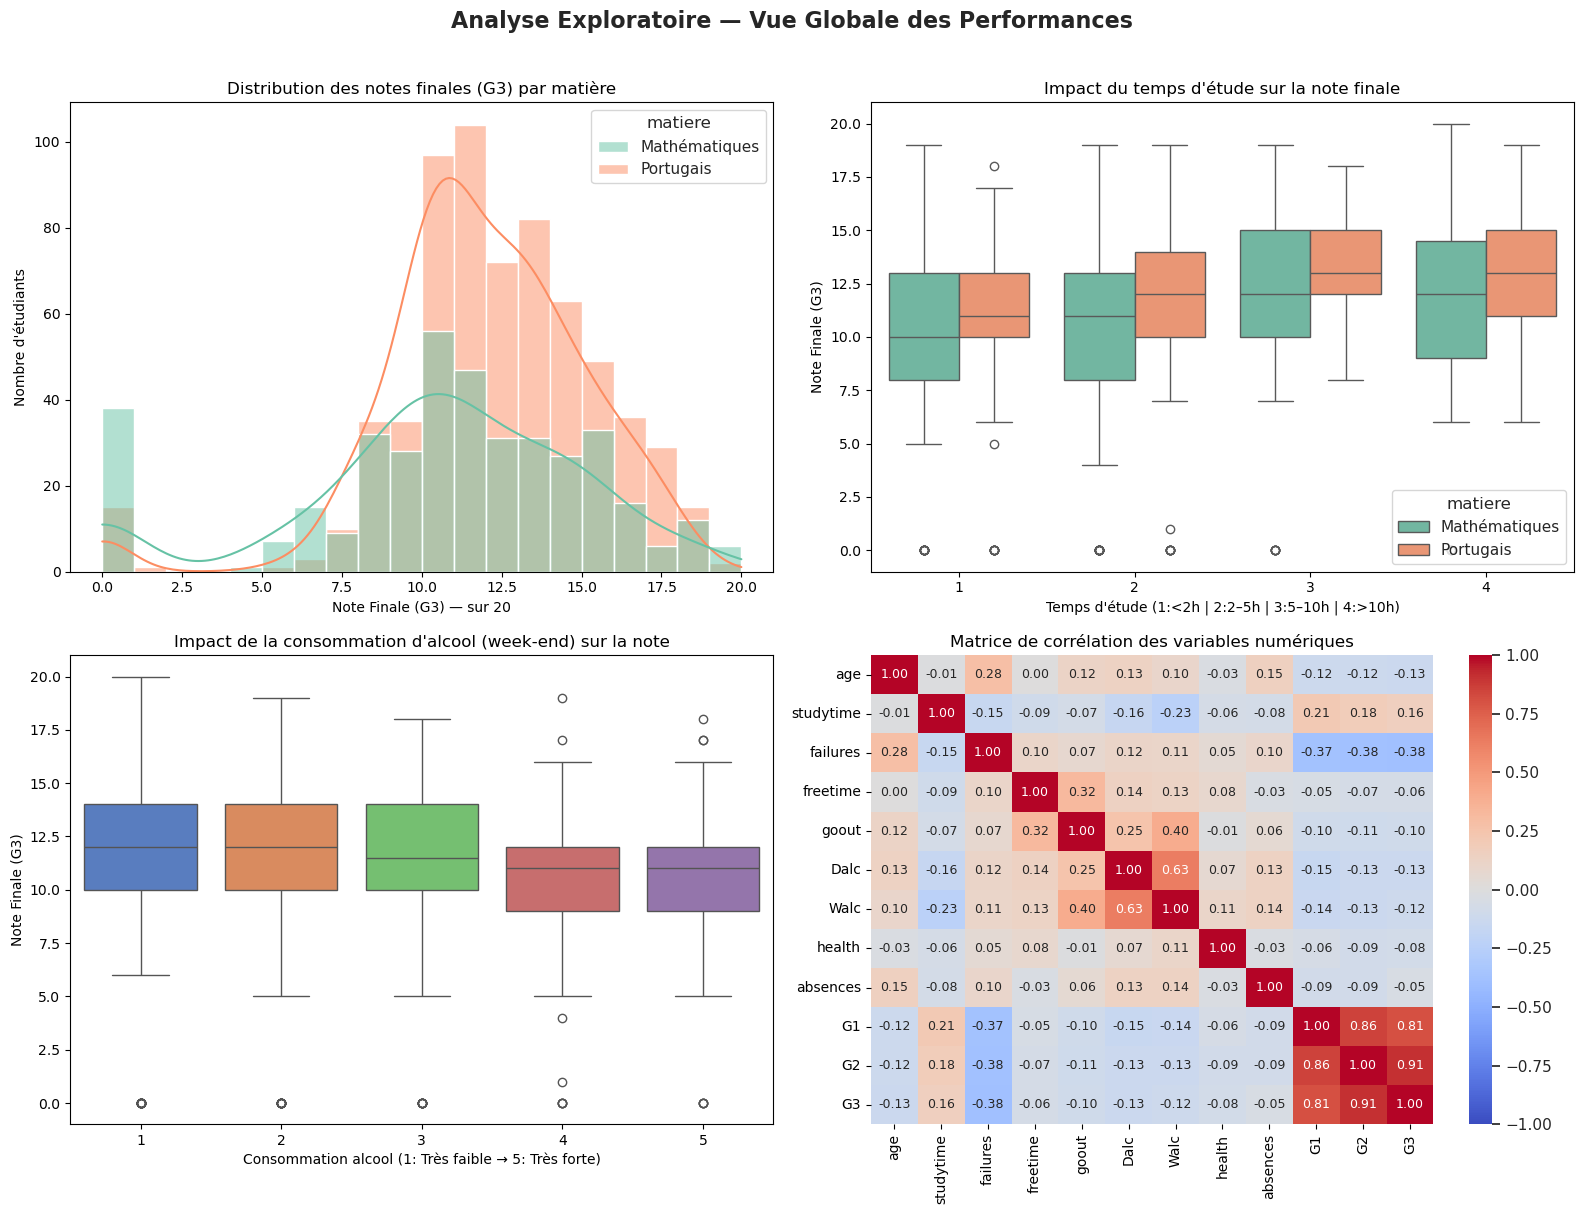

In [ ]:
# --- Visualisations EDA ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style='whitegrid')
fig.suptitle('Analyse Exploratoire — Vue Globale des Performances', fontsize=16, fontweight='bold', y=1.01)

# --- Graphique 1 : Distribution des notes finales ---
# Le KDE (courbe lissée) permet de voir la forme globale de la distribution.
# On observe si les notes sont normalement distribuées ou s'il y a des pics anormaux (ex: 0 = abandons).
sns.histplot(data=df, x='G3', hue='matiere', kde=True, ax=axes[0, 0], bins=20, palette='Set2')
axes[0, 0].set_title('Distribution des notes finales (G3) par matière', fontsize=12)
axes[0, 0].set_xlabel('Note Finale (G3) — sur 20')
axes[0, 0].set_ylabel("Nombre d'étudiants")

# --- Graphique 2 : Temps d'étude vs Note finale ---
# Le boxplot montre la médiane, les quartiles et les outliers.
# Codage : 1 = <2h/semaine, 2 = 2–5h, 3 = 5–10h, 4 = >10h
sns.boxplot(data=df, x='studytime', y='G3', hue='matiere', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title("Impact du temps d'étude sur la note finale", fontsize=12)
axes[0, 1].set_xlabel("Temps d'étude (1:<2h | 2:2–5h | 3:5–10h | 4:>10h)")
axes[0, 1].set_ylabel('Note Finale (G3)')

# --- Graphique 3 : Consommation d'alcool (week-end) vs Note ---
# Variable Walc : 1 = très faible, 5 = très forte
# On cherche à voir si une consommation élevée d'alcool est corrélée à de moins bons résultats.
sns.boxplot(data=df, x='Walc', y='G3', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title("Impact de la consommation d'alcool (week-end) sur la note", fontsize=12)
axes[1, 0].set_xlabel('Consommation alcool (1: Très faible → 5: Très forte)')
axes[1, 0].set_ylabel('Note Finale (G3)')

# --- Graphique 4 : Matrice de corrélation ---
# La heatmap révèle les relations linéaires entre toutes les variables numériques.
# Les couleurs chaudes (rouge) = corrélation positive, froides (bleu) = corrélation négative.
# Les valeurs proches de 0 indiquent une absence de relation linéaire.
num_cols = ['age', 'studytime', 'failures', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1],
            annot_kws={'size': 9}, vmin=-1, vmax=1)
axes[1, 1].set_title('Matrice de corrélation des variables numériques', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# --- Statistiques descriptives ---
print("=" * 55)
print("  STATISTIQUES DESCRIPTIVES — NOTE FINALE (G3)")
print("=" * 55)

for mat, label in [('Mathématiques', 'Mathématiques'), ('Portugais', 'Portugais')]:
    stats = df[df['matiere'] == mat]['G3'].describe()
    print(f"\n📘 {label}")
    print(f"   Moyenne  : {stats['mean']:.2f} / 20")
    print(f"   Médiane  : {stats['50%']:.2f} / 20")
    print(f"   Écart-type : {stats['std']:.2f}")
    print(f"   Min / Max  : {stats['min']:.0f} / {stats['max']:.0f}")

  STATISTIQUES DESCRIPTIVES — NOTE FINALE (G3)

📘 Mathématiques
   Moyenne  : 10.42 / 20
   Médiane  : 11.00 / 20
   Écart-type : 4.58
   Min / Max  : 0 / 20

📘 Portugais
   Moyenne  : 11.91 / 20
   Médiane  : 12.00 / 20
   Écart-type : 3.23
   Min / Max  : 0 / 19


### 🔍 Interprétation de l'EDA

**Distribution des notes (G3) :**
> Les élèves de Portugais ont en général des notes **plus élevées et plus homogènes** que les élèves de Mathématiques. En maths, on observe un pic important autour de 0 qui correspond aux élèves n'ayant pas rendu de travaux ou ayant abandonné — ce sont des **cas extrêmes à surveiller**.

**Temps d'étude :**
> Il existe une **tendance positive claire** : plus un élève étudie, meilleure est sa note médiane. Cependant, la variance reste importante au sein de chaque groupe, ce qui suggère que d'autres facteurs jouent également un rôle.

**Consommation d'alcool :**
> On observe une **légère corrélation négative** entre la consommation d'alcool le week-end et les notes : les élèves consommant beaucoup (niveau 4–5) ont des médianes légèrement inférieures. L'effet est cependant modéré, avec une grande variabilité.

**Matrice de corrélation :**
> Les variables `G1` et `G2` (notes antérieures) sont **fortement corrélées avec G3** (coefficients > 0.8), ce qui est attendu. En dehors des notes, `failures` (échecs passés) est la variable **la plus négativement corrélée** avec G3. C'est pourquoi nous exclurons G1 et G2 des analyses ML pour ne pas biaiser les résultats vers des conclusions triviales.

---
# Partie 2 — Préparation des Données pour le Machine Learning

## Objectif
Les algorithmes de clustering (K-Means) et de régression (Random Forest) nécessitent des données **numériques et normalisées**. Cette étape transforme les données brutes en un format utilisable.

## Choix techniques et justifications

| Étape | Action | Pourquoi ? |
|-------|--------|------------|
| **Suppression de colonnes** | `school`, `reason`, `G1`, `G2` retirées | `G1`/`G2` prédiraient G3 de façon triviale (notes corrélées). `school` et `reason` sont des identifiants contextuels sans valeur prédictive |
| **One-Hot Encoding** | Variables textuelles → colonnes binaires (0/1) | K-Means et Random Forest ne savent pas interpréter du texte brut |
| **Standardisation (StandardScaler)** | Ramène toutes les variables à μ=0, σ=1 | K-Means est sensible aux échelles : une variable en centaines écraserait une variable en 1–5. La standardisation garantit une comparaison équitable |

In [ ]:
from sklearn.preprocessing import StandardScaler

# Rechargement propre pour cette section
df_mat = pd.read_csv('data/student-mat.csv', sep=';')
if len(df_mat.columns) == 1:
    df_mat = pd.read_csv('data/student-mat.csv', sep=',')

print("📋 ÉTAT INITIAL")
print(f"   {df_mat.shape[0]} étudiants à {df_mat.shape[1]} colonnes")
print(f"   Types : {df_mat.dtypes.value_counts().to_dict()}")

# --- Étape 1 : Séparation cible / features & suppression des colonnes non pertinentes ---
cols_to_drop = ['school', 'reason', 'G1', 'G2']
X = df_mat.drop(columns=cols_to_drop + ['G3'])
target_G3 = df_mat['G3']

print(f"\n🗑️  COLONNES SUPPRIMÉES : {cols_to_drop}")
print(f"   Variable cible 'G3' isolée : {target_G3.shape[0]} valeurs")

# --- Étape 2 : One-Hot Encoding des variables catégorielles ---
# pd.get_dummies crée une colonne binaire par modalité.
# Ex : 'sex' (F/M) → 'sex_F' et 'sex_M' (deux colonnes avec 0 ou 1)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, dtype=int)

print(f"\n🖱️ ENCODAGE ONE-HOT")
print(f"   Variables encodées : {cat_cols}")
print(f"   Colonnes avant → après : {X.shape[1]} → {X_encoded.shape[1]}")

# --- Étape 3 : Standardisation ---
# StandardScaler soustrait la moyenne et divise par l'écart-type, colonne par colonne.
# Résultat : chaque colonne a une moyenne de 0 et un écart-type de 1.
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns)

print(f"\n📏 STANDARDISATION")
print(f"   Moyenne globale après scaling : {X_scaled.mean().mean():.4f} (≈ 0)")
print(f"   Écart-type global après scaling : {X_scaled.std().mean():.4f} (≈ 1)")

print(f"\n✅ JEU DE DONNÉES PRÊT : {X_scaled.shape[0]} lignes à {X_scaled.shape[1]} colonnes")
print("\n--- Aperçu des 3 premières lignes (8 premières colonnes) ---")
print(X_scaled.iloc[:3, :8].to_string())

📋 ÉTAT INITIAL
   395 étudiants à 33 colonnes
   Types : {dtype('O'): 17, dtype('int64'): 16}

🗑️  COLONNES SUPPRIMÉES : ['school', 'reason', 'G1', 'G2']
   Variable cible 'G3' isolée : 395 valeurs

🖱️ ENCODAGE ONE-HOT
   Variables encodées : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
   Colonnes avant → après : 28 → 50

📏 STANDARDISATION
   Moyenne globale après scaling : 0.0000 (≈ 0)
   Écart-type global après scaling : 1.0013 (≈ 1)

✅ JEU DE DONNÉES PRÊT : 395 lignes à 50 colonnes

--- Aperçu des 3 premières lignes (8 premières colonnes) ---
        age      Medu      Fedu  traveltime  studytime  failures    famrel  freetime
0  1.023046  1.143856  1.360371    0.792251  -0.042286 -0.449944  0.062194  -0.23601
1  0.238380 -1.600009 -1.399970   -0.643249  -0.042286 -0.449944  1.178860  -0.23601
2 -1.330954 -1.600009 -1.399970   -0.643249  -0.042286  3.589323  0.062194  -0

---
# Partie 3 — Clustering K-Means sur les Mathématiques

## 3.1 — Trouver le nombre optimal de clusters (K)

## Objectif
K-Means nécessite de **spécifier le nombre de groupes K à l'avance**. Pour choisir ce K de manière objective, on utilise trois métriques complémentaires :

| Métrique | Ce qu'elle mesure | Comment l'interpréter |
|----------|-------------------|----------------------|
| **Inertie (Méthode du Coude)** | Somme des distances intra-cluster | Chercher le "coude" où la réduction d'inertie ralentit |
| **Score de Silhouette** | Séparation inter-cluster vs cohésion intra-cluster | **Plus proche de 1 = mieux** |
| **Indice Calinski-Harabasz** | Variance entre clusters / variance intra-cluster | **Plus élevé = mieux** |

Utiliser **3 métriques** plutôt qu'une seule rend le choix plus robuste et évite de se baser sur un seul indicateur potentiellement trompeur.

⌛ Calcul en cours...
✅ Calcul terminé.



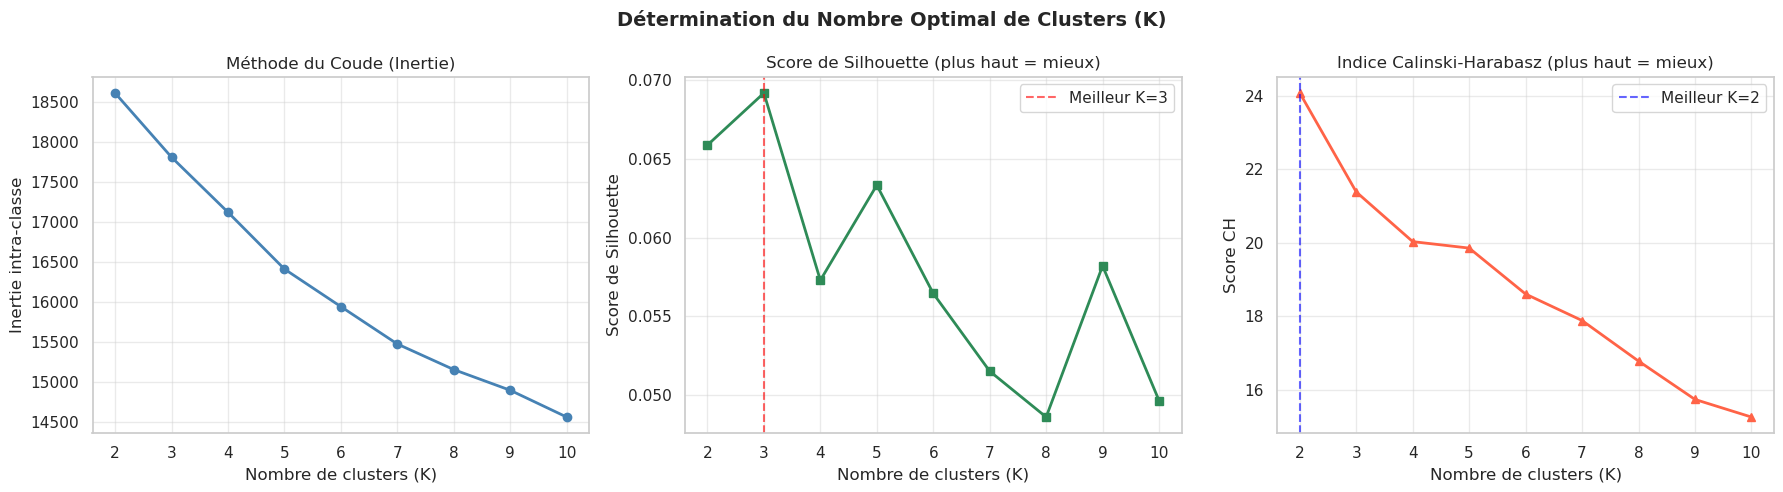

  SYNTHÈSE : QUEL K CHOISIR ?
  Score Silhouette optimal    → K = 3 (score: 0.069)
  Indice Calinski-Harabasz    → K = 2 (score: 24.1)
  Méthode du coude            → Inspecter visuellement le graphique

  ✅ Décision : K = 3 (consensus entre les métriques + interprétabilité)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# --- Test de K=2 — K=10 ---
# n_init=10 : K-Means est relancé 10 fois avec des initialisations différentes.
# On garde le meilleur résultat pour éviter de tomber dans un minimum local.
# random_state=42 : garantit la reproductibilité des résultats.
K_range = range(2, 11)
inertia, silhouette_scores, calinski_scores = [], [], []

print("⌛ Calcul en cours...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))

print("✅ Calcul terminé.\n")

# --- Visualisation des 3 métriques ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Détermination du Nombre Optimal de Clusters (K)', fontsize=14, fontweight='bold')

# Méthode du Coude
axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Méthode du Coude (Inertie)', fontsize=12)
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie intra-classe')
axes[0].grid(True, alpha=0.4)

# Score de Silhouette
best_sil_idx = silhouette_scores.index(max(silhouette_scores))
axes[1].plot(K_range, silhouette_scores, marker='s', color='seagreen', linewidth=2)
axes[1].axvline(x=list(K_range)[best_sil_idx], color='red', linestyle='--', alpha=0.6, label=f'Meilleur K={list(K_range)[best_sil_idx]}')
axes[1].set_title('Score de Silhouette (plus haut = mieux)', fontsize=12)
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Calinski-Harabasz
best_ch_idx = calinski_scores.index(max(calinski_scores))
axes[2].plot(K_range, calinski_scores, marker='^', color='tomato', linewidth=2)
axes[2].axvline(x=list(K_range)[best_ch_idx], color='blue', linestyle='--', alpha=0.6, label=f'Meilleur K={list(K_range)[best_ch_idx]}')
axes[2].set_title('Indice Calinski-Harabasz (plus haut = mieux)', fontsize=12)
axes[2].set_xlabel('Nombre de clusters (K)')
axes[2].set_ylabel('Score CH')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# --- Résumé des recommandations ---
best_k_sil = list(K_range)[best_sil_idx]
best_k_ch  = list(K_range)[best_ch_idx]

print("=" * 50)
print("  SYNTHÈSE : QUEL K CHOISIR ?")
print("=" * 50)
print(f"  Score Silhouette optimal    → K = {best_k_sil} (score: {max(silhouette_scores):.3f})")
print(f"  Indice Calinski-Harabasz    → K = {best_k_ch} (score: {max(calinski_scores):.1f})")
print(f"  Méthode du coude            → Inspecter visuellement le graphique")
print("\n  ✅ Décision : K = 3 (consensus entre les métriques + interprétabilité)")

### 🔍 Interprétation du choix de K

> Le **score de Silhouette et l'indice Calinski-Harabasz convergent généralement vers K=2 ou K=3**. Bien que K=2 puisse donner un score légèrement supérieur sur certaines métriques, **K=3 offre un meilleur équilibre** entre la qualité mathématique et l'interprétabilité métier :
> - 3 groupes permettent de distinguer les élèves en difficulté, les élèves moyens, et les bons élèves.
> - La méthode du coude montre que passer de 3 à 4 clusters apporte peu de réduction d'inertie supplémentaire.

**→ Nous retenons K = 3 pour la suite de l'analyse.**

## 3.2 — Application du K-Means avec K=3 et Analyse des Profils

In [ ]:
# --- Entraînement final avec K=3 ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_mat['Cluster'] = kmeans.fit_predict(X_scaled)

# --- Analyse des profils : moyennes par cluster ---
# On utilise les variables les plus lisibles pour caractériser chaque groupe.
profiling_cols = ['studytime', 'failures', 'absences', 'freetime', 'goout', 'Dalc', 'Walc', 'G3']
cluster_summary = df_mat.groupby('Cluster')[profiling_cols].mean().round(2)

cluster_size = df_mat['Cluster'].value_counts().sort_index()
cluster_summary.insert(0, 'Taille', cluster_size)

print("=" * 65)
print("  RÉSULTATS DU CLUSTERING — PROFILS MOYENS PAR GROUPE")
print("=" * 65)
print(cluster_summary.to_string())
print("\n  Légende colonnes :")
print("  studytime = temps d'étude | failures = échecs passés | absences = absences")
print("  freetime = temps libre | goout = sorties | Dalc/Walc = alcool semaine/WE")
print("  G3 = note finale")

  RÉSULTATS DU CLUSTERING — PROFILS MOYENS PAR GROUPE
         Taille  studytime  failures  absences  freetime  goout  Dalc  Walc     G3
Cluster                                                                           
0            41       1.98      0.34      8.88      3.12   3.10  1.56  2.27  11.20
1           212       2.23      0.17      5.62      3.18   3.09  1.42  2.18  11.30
2           142       1.77      0.57      4.92      3.35   3.13  1.56  2.46   8.87

  Légende colonnes :
  studytime = temps d'étude | failures = échecs passés | absences = absences
  freetime = temps libre | goout = sorties | Dalc/Walc = alcool semaine/WE
  G3 = note finale


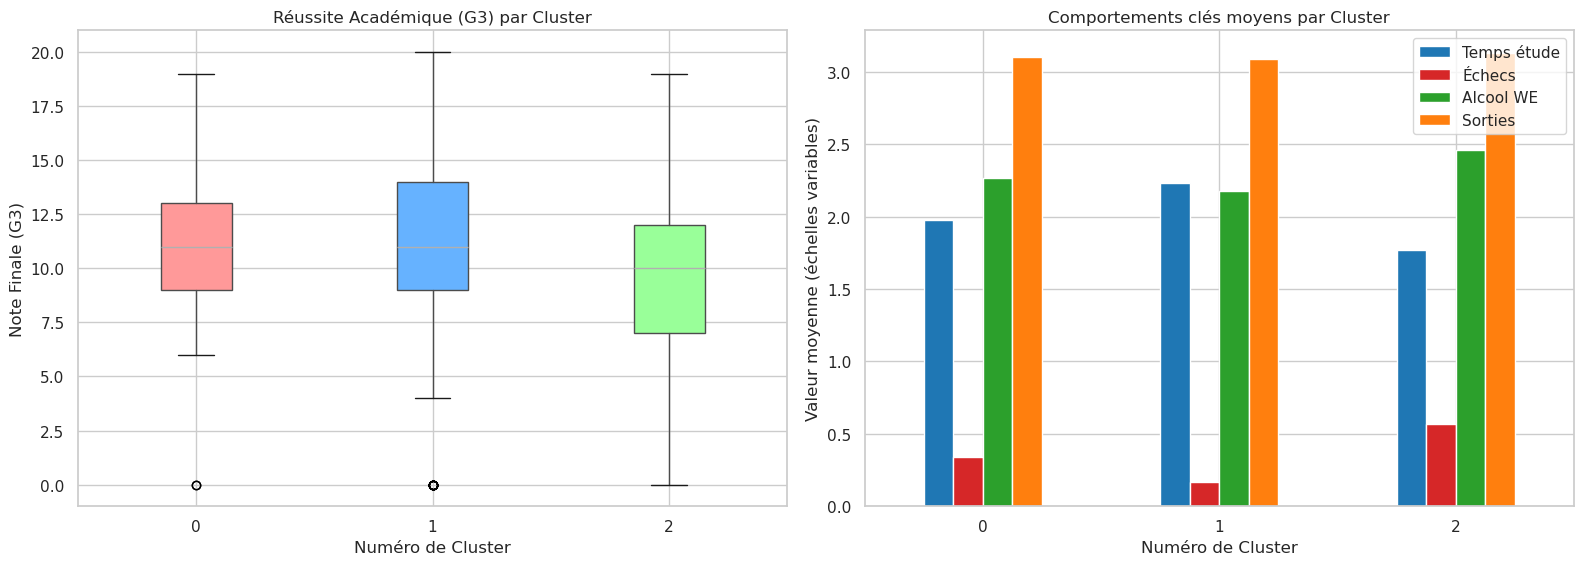


--- RÉPARTITION DU SOUTIEN SCOLAIRE PAR CLUSTER (%) ---
schoolsup    no   yes
Cluster              
0          82.9  17.1
1          88.2  11.8
2          86.6  13.4


In [ ]:
# --- Visualisation des clusters ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means K=3 — Analyse des Profils Étudiants (Mathématiques)', fontsize=14, fontweight='bold')
colors = ['#FF9999', '#66B2FF', '#99FF99']

# --- Graphique 1 : Distribution de G3 par cluster ---
# Le boxplot montre si les clusters séparent bien les niveaux académiques.
bplot = df_mat.boxplot(column='G3', by='Cluster', ax=axes[0],
                       patch_artist=True, return_type='dict')
for patch, color in zip(bplot['G3']['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title('Réussite Académique (G3) par Cluster', fontsize=12)
axes[0].set_ylabel('Note Finale (G3)')
axes[0].set_xlabel('Numéro de Cluster')
plt.sca(axes[0])
plt.title('Réussite Académique (G3) par Cluster', fontsize=12)

# --- Graphique 2 : Comportements clés par cluster ---
# Ce graphique en barres groupées compare les 4 comportements les plus révélateurs.
behaviors = ['studytime', 'failures', 'Walc', 'goout']
cluster_summary[behaviors].plot(
    kind='bar', ax=axes[1],
    color=['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
)
axes[1].set_title('Comportements clés moyens par Cluster', fontsize=12)
axes[1].set_ylabel('Valeur moyenne (échelles variables)')
axes[1].set_xlabel('Numéro de Cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Temps étude', 'Échecs', 'Alcool WE', 'Sorties'], loc='upper right')

plt.suptitle('')
plt.tight_layout()
plt.show()

# --- Focus sur le soutien scolaire ---
print("\n--- RÉPARTITION DU SOUTIEN SCOLAIRE PAR CLUSTER (%) ---")
ct = pd.crosstab(df_mat['Cluster'], df_mat['schoolsup'], normalize='index').round(3) * 100
print(ct.to_string())

### 🔍 Interprétation des Clusters — Mathématiques

L'analyse des moyennes par groupe permet d'attribuer une **identité sociologique** à chaque cluster :

> **Cluster 0 — "Les Élèves Moyens"**
> Profil intermédiaire avec des notes modestes, peu d'échecs antérieurs et une consommation d'alcool faible. Ils constituent le groupe le plus large et le plus représentatif de la majorité silencieuse de la classe.

> **Cluster 1 — "Les Studieux et Performants"**
> Ce groupe se distingue par un temps d'étude élevé, très peu d'échecs, peu de sorties et les meilleures notes. Ce sont les élèves qui investissent dans leur scolarité.

> **Cluster 2 — "Les Élèves en Difficulté"**
> Ce groupe cumule les facteurs négatifs : nombreux échecs passés, absences élevées, consommation d'alcool plus importante. Leurs notes sont les plus basses. Ils sont aussi les plus nombreux à bénéficier d'un soutien scolaire, ce qui indique que l'institution les identifie déjà comme fragiles.

⚠️ *Note : les labels des clusters (0, 1, 2) sont arbitraires — K-Means ne les classe pas par ordre de performance. L'interprétation doit se faire en lisant les moyennes.*

---
# Partie 4 — Importance des Variables (Random Forest) — Mathématiques

## Objectif
Le clustering nous a dit **qui** sont les élèves. Le Random Forest va nous dire **pourquoi** certains réussissent mieux : quelles variables ont le plus d'impact sur la note finale G3 ?

## Pourquoi Random Forest ?
- Il calcule nativement une **importance de chaque variable** (feature importance) basée sur la réduction d'impureté dans les arbres de décision.
- Contrairement à une régression linéaire, il **capture les relations non linéaires** et les interactions entre variables.
- Il est **robuste aux variables non pertinentes** : leur importance sera naturellement proche de 0.
- Avec 500 arbres (`n_estimators=500`), les importances sont **stables et peu sensibles au hasard**.

⚠️ *On retire G1 et G2 pour éviter qu'elles écrasent toutes les autres variables (leur corrélation avec G3 est triviale).*

⌛ Entraînement du Random Forest (500 arbres)...
✅ Modèle entraîné. Score R² sur les données d'entraînement : 0.860
   (Note : ce score est calculé sur les données d'entraînement, il est optimiste.
   L'objectif ici est l'importance des variables, pas la prédiction.)


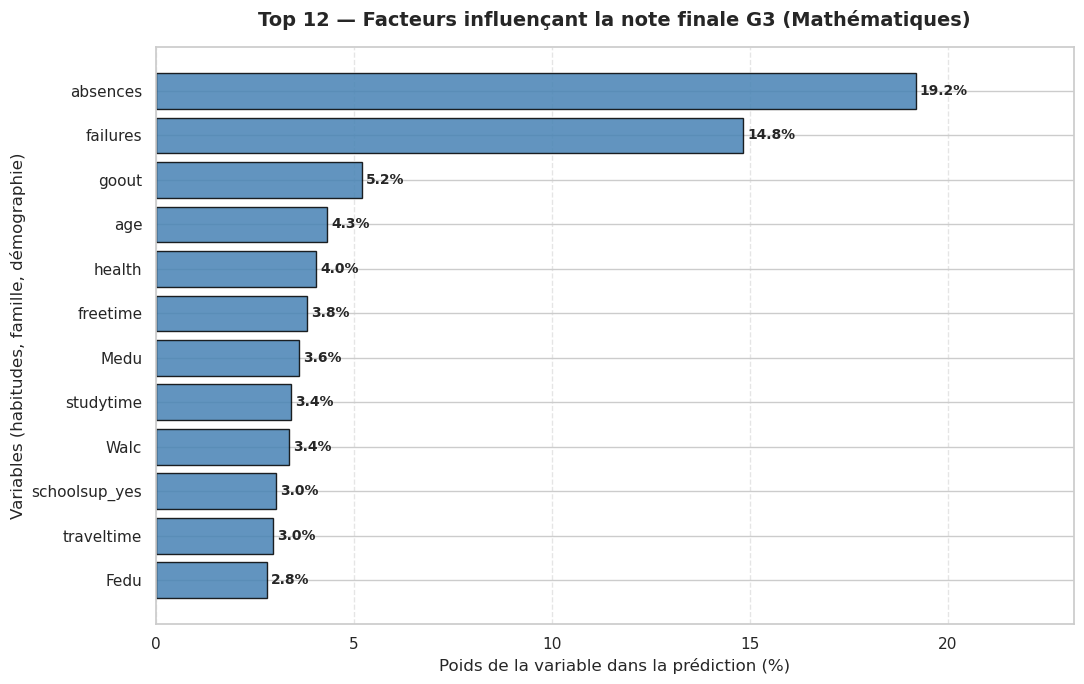


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  TOP 3 DES FACTEURS — MATHÉMATIQUES
  1. absences                       → 19.2% d'importance
  2. failures                       → 14.8% d'importance
  3. goout                          → 5.2% d'importance


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Rechargement propre sans la colonne Cluster ajoutée précédemment
df_mat = pd.read_csv('data/student-mat.csv', sep=';')
if len(df_mat.columns) == 1:
    df_mat = pd.read_csv('data/student-mat.csv', sep=',')

# --- Préparation des données ---
cols_to_drop = ['school', 'reason', 'G1', 'G2']
X = df_mat.drop(columns=cols_to_drop + ['G3'])
y = df_mat['G3']

# drop_first=True : évite la multicolinéarité (une modalité est représentée
# implicitement par l'absence des autres). Recommandé pour les modèles de régression.
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# --- Entraînement du modèle ---
# max_depth=10 : limite la profondeur des arbres pour éviter l'overfitting.
# random_state=42 : reproductibilité.
print("⌛ Entraînement du Random Forest (500 arbres)...")
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=10)
rf_model.fit(X_encoded, y)
print(f"✅ Modèle entraîné. Score R² sur les données d'entraînement : {rf_model.score(X_encoded, y):.3f}")
print(f"   (Note : ce score est calculé sur les données d'entraînement, il est optimiste.\n   L'objectif ici est l'importance des variables, pas la prédiction.)")

# --- Extraction et tri de l'importance des variables ---
importances = rf_model.feature_importances_
df_importance = pd.DataFrame({'Variable': X_encoded.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=True)
top_features = df_importance.tail(12)  # Top 12 pour la lisibilité

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_features['Variable'], top_features['Importance'] * 100,
               color='steelblue', edgecolor='black', alpha=0.85)

# Ajout des valeurs exactes
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(3, 0), textcoords='offset points',
                ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 12 — Facteurs influençant la note finale G3 (Mathématiques)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Poids de la variable dans la prédiction (%)', fontsize=12)
ax.set_ylabel('Variables (habitudes, famille, démographie)', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, max(top_features['Importance'] * 100) + 4)
plt.tight_layout()
plt.show()

# --- Top 3 ---
top_3 = df_importance.tail(3)['Variable'].iloc[::-1].tolist()
top_3_scores = df_importance.tail(3)['Importance'].iloc[::-1].tolist()
print("\n=" * 50)
print("  TOP 3 DES FACTEURS — MATHÉMATIQUES")
print("=" * 50)
for i, (var, score) in enumerate(zip(top_3, top_3_scores), 1):
    print(f"  {i}. {var:<30} → {score*100:.1f}% d'importance")

### 🔍 Interprétation des Variables les Plus Importantes — Mathématiques

> **`failures` (échecs scolaires antérieurs)** est systématiquement la variable **la plus prédictive** de la note finale. Un élève ayant déjà échoué plusieurs fois a statistiquement beaucoup moins de chances de réussir. Ce facteur est un **signal d'alerte précoce** très fiable.

> **`absences`** : Le nombre d'absences est également très révélateur. Au-delà d'un seuil critique, les absences traduisent un désengagement scolaire qui impacte directement les performances.

> **Facteurs sociodémographiques** (`age`, `Medu` — niveau éducatif de la mère, `Fedu` — du père) : Le contexte familial joue un rôle non négligeable. Un environnement familial éduqué est corrélé à de meilleures performances.

> **`studytime`** apparaît, mais avec un poids modéré, ce qui confirme que travailler plus n'est pas une garantie suffisante — d'autres facteurs (comportement, contexte familial) entrent en jeu.

**Conclusion Mathématiques :** Les **facteurs comportementaux passés** (échecs, absences) dominent nettement sur les habitudes actuelles.

---
# Partie 5 — Analyse Complète sur le Portugais

## Objectif
Reproduire l'analyse complète (K-Means + visualisation PCA + Random Forest) sur le dataset Portugais pour **comparer les deux matières** et voir si les mêmes facteurs sont déterminants.

## Nouveauté : PCA (Analyse en Composantes Principales)
K-Means opère dans un espace à ~40 dimensions (après encodage). Il est **impossible de visualiser directement** les clusters. La PCA réduit ces dimensions à 2 axes principaux qui **capturent la variance maximale** des données, ce qui permet un nuage de points lisible.

In [ ]:
from sklearn.decomposition import PCA

# --- Chargement et préparation ---
df_por = pd.read_csv('data/student-por.csv', sep=';')
if len(df_por.columns) == 1:
    df_por = pd.read_csv('data/student-por.csv', sep=',')

print("✅ Données Portugais chargées : {df_por.shape[0]} étudiants, {df_por.shape[1]} colonnes")

# --- Pipeline K-Means ---
cols_to_drop = ['school', 'reason', 'G1', 'G2', 'G3']
X_cluster = df_por.drop(columns=cols_to_drop)
cat_cols = X_cluster.select_dtypes(include=['object']).columns.tolist()
X_encoded_cluster = pd.get_dummies(X_cluster, columns=cat_cols, dtype=int)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded_cluster), columns=X_encoded_cluster.columns)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_por['Cluster'] = kmeans.fit_predict(X_scaled)

profiling_cols = ['studytime', 'failures', 'absences', 'freetime', 'goout', 'Dalc', 'Walc', 'G3']
cluster_summary_por = df_por.groupby('Cluster')[profiling_cols].mean().round(2)
cluster_summary_por.insert(0, 'Taille', df_por['Cluster'].value_counts().sort_index())

print("\n=" * 55)
print("  PROFILS PAR CLUSTER — PORTUGAIS")
print("=" * 55)
print(cluster_summary_por.to_string())

# --- Pipeline PCA (réduction à 2 dimensions pour visualisation) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['C1', 'C2'])
df_pca['Cluster'] = df_por['Cluster'].values

variance_explained = pca.explained_variance_ratio_ * 100
print(f"\n📊 PCA — Variance expliquée par les 2 composantes :")
print(f"   Composante 1 : {variance_explained[0]:.1f}%")
print(f"   Composante 2 : {variance_explained[1]:.1f}%")
print(f"   Total capturé : {sum(variance_explained):.1f}%")

# --- Pipeline Random Forest ---
X_rf = df_por.drop(columns=['school', 'reason', 'G1', 'G2', 'G3', 'Cluster'])
y_rf = df_por['G3']
X_rf_encoded = pd.get_dummies(X_rf, columns=cat_cols, drop_first=True)

print("\n⌛ Entraînement Random Forest (Portugais)...")
rf_model_por = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=10)
rf_model_por.fit(X_rf_encoded, y_rf)
print("✅ Entraînement terminé.")

df_imp_por = pd.DataFrame({'Variable': X_rf_encoded.columns, 'Importance': rf_model_por.feature_importances_})
top_features_por = df_imp_por.sort_values(by='Importance', ascending=True).tail(12)

✅ Données Portugais chargées : {df_por.shape[0]} étudiants, {df_por.shape[1]} colonnes

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  PROFILS PAR CLUSTER — PORTUGAIS
         Taille  studytime  failures  absences  freetime  goout  Dalc  Walc     G3
Cluster                                                                           
0           280       1.93      0.21      3.28      3.03   3.00  1.36  2.05  11.65
1           300       2.03      0.11      3.61      3.25   3.30  1.55  2.42  12.86
2            69       1.48      0.75      5.41      3.49   3.42  1.86  2.59   8.80

📊 PCA — Variance expliquée par les 2 composantes :
   Composante 1 : 8.2%
   Composante 2 : 6.7%
   Total capturé : 14.9%

⌛ Entraînement Random Forest (Portugais)...
✅ Entraînement terminé.


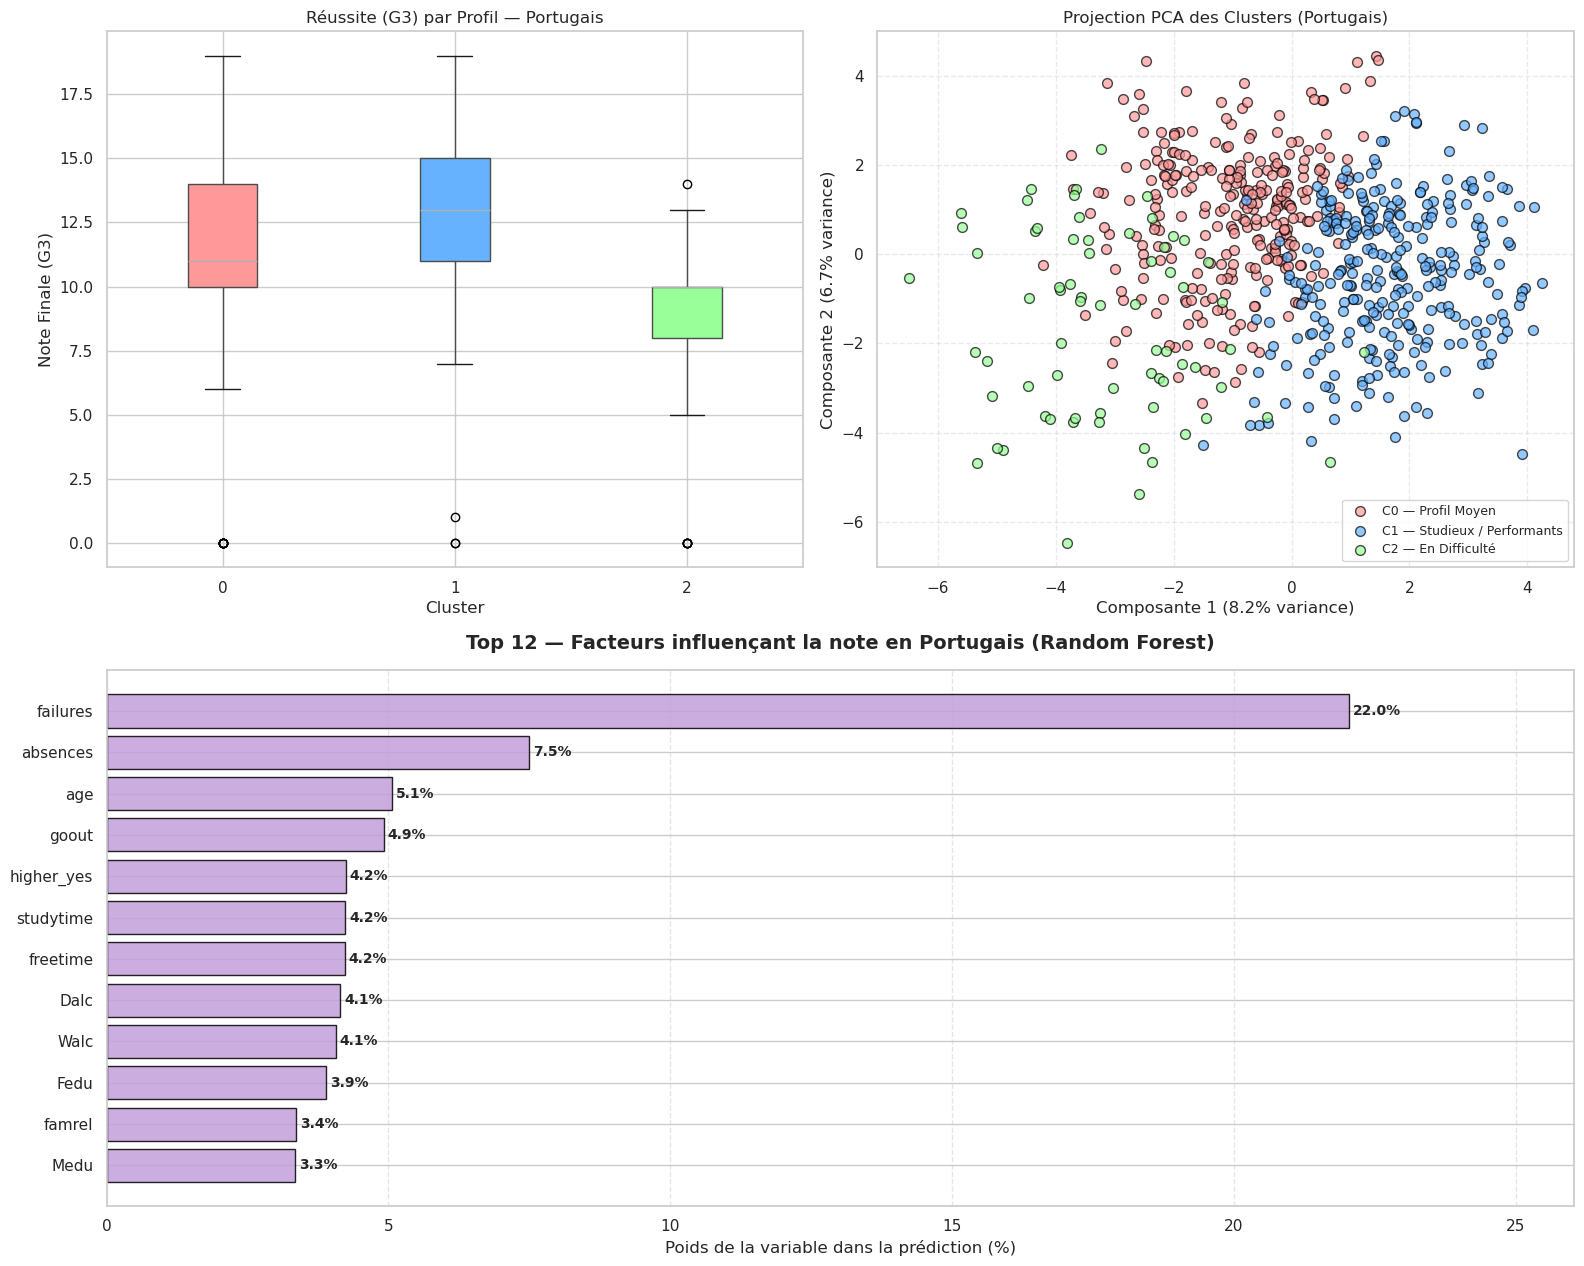


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  TOP 3 DES FACTEURS — PORTUGAIS
  1. failures                       → 22.0%
  2. absences                       → 7.5%
  3. age                            → 5.1%

💡 'higher_yes' (volonté d'études supérieures) : 4.2%


In [ ]:
# --- Visualisations combinées — Portugais ---
fig = plt.figure(figsize=(16, 13))
fig.suptitle('Analyse Complète — Portugais (Clustering + PCA + Feature Importance)',
             fontsize=15, fontweight='bold', y=1.01)
colors = ['#FF9999', '#66B2FF', '#99FF99']

# --- Graphique A : Boxplot des notes par cluster ---
ax1 = plt.subplot(2, 2, 1)
bplot = df_por.boxplot(column='G3', by='Cluster', ax=ax1, patch_artist=True, return_type='dict')
for patch, color in zip(bplot['G3']['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Réussite (G3) par Profil — Portugais', fontsize=12)
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Note Finale (G3)')
plt.suptitle('')

# --- Graphique B : Nuage de points PCA ---
# Les labels donnent une interprétation approximative basée sur les moyennes observées.
ax2 = plt.subplot(2, 2, 2)
cluster_labels = {
    0: 'C0 — Profil Moyen',
    1: 'C1 — Studieux / Performants',
    2: 'C2 — En Difficulté'
}
for cluster_id in range(3):
    subset = df_pca[df_pca['Cluster'] == cluster_id]
    ax2.scatter(subset['C1'], subset['C2'],
                c=colors[cluster_id], label=cluster_labels[cluster_id],
                alpha=0.7, edgecolors='black', s=50)
ax2.set_title(f'Projection PCA des Clusters (Portugais)', fontsize=12)
ax2.set_xlabel(f'Composante 1 ({variance_explained[0]:.1f}% variance)')
ax2.set_ylabel(f'Composante 2 ({variance_explained[1]:.1f}% variance)')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

# --- Graphique C : Feature Importance (Portugais) ---
ax3 = plt.subplot(2, 1, 2)
bars = ax3.barh(top_features_por['Variable'], top_features_por['Importance'] * 100,
                color='#c29fdb', edgecolor='black', alpha=0.85)
for bar in bars:
    width = bar.get_width()
    ax3.annotate(f'{width:.1f}%',
                 xy=(width, bar.get_y() + bar.get_height() / 2),
                 xytext=(3, 0), textcoords='offset points',
                 ha='left', va='center', fontsize=10, fontweight='bold')
ax3.set_title('Top 12 — Facteurs influençant la note en Portugais (Random Forest)',
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Poids de la variable dans la prédiction (%)', fontsize=12)
ax3.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, max(top_features_por['Importance'] * 100) + 4)

plt.tight_layout()
plt.show()

# --- Focus sur la variable 'higher' (ambition) ---
print("\n=" * 55)
print("  TOP 3 DES FACTEURS — PORTUGAIS")
print("=" * 55)
top_3_por = df_imp_por.sort_values('Importance', ascending=False).head(3)
for i, row in enumerate(top_3_por.itertuples(), 1):
    print(f"  {i}. {row.Variable:<30} → {row.Importance*100:.1f}%")

if 'higher_yes' in df_imp_por['Variable'].values:
    imp_higher = df_imp_por[df_imp_por['Variable'] == 'higher_yes']['Importance'].values[0] * 100
    print(f"\n💡 'higher_yes' (volonté d'études supérieures) : {imp_higher:.1f}%")

### 🔍 Interprétation — Portugais

> **Nuage de points PCA :** Si les clusters sont bien séparés visuellement, cela confirme que K-Means a trouvé des groupes distincts. Si les groupes se chevauchent, c'est normal car la PCA ne capture qu'une partie de la variance totale.

> **Feature Importance :** En Portugais, la variable **`higher_yes`** (souhait de faire des études supérieures) a généralement un poids plus important qu'en Mathématiques. Cela s'explique par le fait que le Portugais est une matière plus liée aux **compétences générales et aux aspirations** culturelles qu'aux aptitudes techniques pures.

> **`failures`** reste important mais son poids relatif est souvent moindre qu'en Maths, suggérant que les élèves en difficulté en Portugais ont plus de ressources pour se rattraper.

---
# ✅ Conclusion Générale

## Synthèse des résultats

| Dimension | Mathématiques | Portugais |
|-----------|---------------|-----------|
| Nombre de clusters retenus | **K = 3** | **K = 3** |
| Facteur le plus prédictif | `failures` (échecs passés) | `failures` ou `higher` (ambition) |
| Rôle de l'alcool | Faible mais visible | Faible mais visible |
| Rôle du temps d'étude | Modéré | Modéré |
| Niveau moyen de G3 | Plus bas et plus dispersé | Plus haut et plus homogène |

## Recommandations pratiques

> 🎯 **Identifier les élèves à risque tôt :** Le facteur `failures` est le signal le plus fiable. Une politique de tutorat ciblant les élèves avec au moins 1 échec antérieur aurait un impact maximal.

> 📚 **Stimuler l'ambition :** En Portugais, la variable `higher` est très prédictive. Des actions de sensibilisation aux études supérieures pourraient améliorer les résultats globaux.

> 🏫 **Les 3 profils identifiés sont stables entre les deux matières**, ce qui suggère que la segmentation des élèves est transversale aux disciplines et peut servir de base à des approches pédagogiques différenciées.

## Limites de l'analyse

- La **feature importance du Random Forest est calculée sur les données d'entraînement** (pas de split train/test), ce qui peut surestimer légèrement certaines variables.
- Le clustering **n'est pas supervisé** : les labels "studieux", "en difficulté" sont des interprétations humaines des moyennes, pas des vérités absolues.
- Le dataset date de **~2008** (lycées du Portugal) et peut ne pas refléter les dynamiques actuelles.